# Notebook 7: Adaptation Experiment — Drift Simulation & Fine-tuning

Simulates covariate shift (persistent mean-shift in joint coordinates), measures model degradation, then adapts via a short fine-tuning step on the drifted distribution. Reports before/after ADE/FDE and latency.

**Experiment design:**
- `ADAPT_SEQS` sequences used for fine-tuning (adaptation set)
- `EVAL_SEQS` sequences used for evaluation (held out from adaptation)
- K=5 samples for fast evaluation during this experiment

## Section 1: Imports & Setup

In [1]:
import sys, os, copy, time, json
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from types import SimpleNamespace
from tqdm import tqdm

REPO_ROOT = os.path.abspath('../HumanMAC/')
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from config import Config, update_config
from utils import create_logger, seed_set
from utils.script import (create_model_and_diffusion, dataset_split,
                           get_multimodal_gt_full, sample_preprocessing)

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

<IPython.core.display.Javascript object>

PyTorch version : 1.7.1+cu110
CUDA available  : True
GPU             : NVIDIA GeForce RTX 4090


## Section 2: Config, Model & Data

Load the EMA checkpoint. A deep copy is made (`model_adapted`) for fine-tuning so the original weights are preserved for the before-adaptation evaluation.

In [2]:
seed_set(0)
os.chdir(REPO_ROOT)

args = {
    'cfg': 'h36m', 'mode': 'test', 'iter': 0, 'seed': 0,
    'device': torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'),
    'multimodal_threshold': 0.5, 'multimodal_th_high': 0.1,
    'milestone': [75, 150, 225, 275, 350, 450], 'gamma': 0.9,
    'save_model_interval': 10, 'save_gif_interval': 10, 'save_metrics_interval': 100,
    'ckpt': './checkpoints/h36m_ckpt.pt',
    'ema': True, 'vis_switch_num': 10, 'vis_col': 5, 'vis_row': 3,
}

cfg = Config('h36m', test=False)
cfg = update_config(cfg, args)

print(f'Device          : {cfg.device}')
print(f't_his / t_pred  : {cfg.t_his} / {cfg.t_pred}')

Device          : cuda
t_his / t_pred  : 25 / 100


In [4]:
# Load model — original stays frozen; adapted copy will be fine-tuned
model_orig, diffusion = create_model_and_diffusion(cfg)

CKPT_PATH = os.path.join(cfg.model_path, 'ckpt_ema_990.pt')
state_dict = torch.load(CKPT_PATH, map_location=cfg.device)
model_orig.load_state_dict(state_dict)
model_orig.eval()

# Deep copy for adaptation
model_adapted = copy.deepcopy(model_orig)

total_params = sum(p.numel() for p in model_orig.parameters())
print(f'Loaded checkpoint : {CKPT_PATH}')
print(f'Total parameters  : {total_params/1e6:.2f}M')

Loaded checkpoint : results/test_19/models/ckpt_ema_990.pt
Total parameters  : 28.40M


In [5]:
import logging
dataset, dataset_multi_test = dataset_split(cfg)
args_ns = SimpleNamespace(**args)
logger = logging.getLogger('adaptation')
logger.setLevel(logging.INFO)
if not logger.handlers:
    logger.addHandler(logging.StreamHandler())

multimodal_dict = get_multimodal_gt_full(logger, dataset_multi_test, args_ns, cfg)
data_group  = multimodal_dict['data_group']   # (N, t_his+t_pred, joints, 3)
gt_group    = multimodal_dict['gt_group']
traj_gt_arr = multimodal_dict['traj_gt_arr']
num_samples = multimodal_dict['num_samples']

print(f'Test sequences  : {num_samples}')
print(f'data_group shape: {data_group.shape}')

preparing full evaluation dataset...
#1 future: 73/5168
#<10 future: 1011/5168
done...


Test sequences  : 5168
data_group shape: (5168, 125, 17, 3)


## Section 3: Drift Simulation

Simulate **covariate shift** by adding a persistent bias (mean shift) to all non-root joint coordinates in the observed window. This mimics a miscalibrated sensor or a systematic offset in a new deployment domain.

- `DRIFT_BIAS`: amplitude of the coordinate shift (meters)
- Bias direction is fixed (all joints shifted equally along x-axis)

In [6]:
# Experiment config
DRIFT_BIAS  = 0.10   # 10 cm constant shift on non-root joints (x-axis)
ADAPT_SEQS  = 30     # sequences used for fine-tuning
EVAL_SEQS   = 50     # sequences for before/after evaluation
K_EVAL      = 5      # prediction samples (fast eval)
ADAPT_STEPS = 30     # fine-tuning gradient steps
ADAPT_LR    = 1e-5   # low LR for conservative adaptation

rng = np.random.default_rng(7)
all_idx = rng.permutation(num_samples)

adapt_idx = all_idx[:ADAPT_SEQS]
eval_idx  = all_idx[ADAPT_SEQS : ADAPT_SEQS + EVAL_SEQS]

def inject_drift(data, bias=DRIFT_BIAS):
    """Add persistent x-axis bias to observed frames (non-root joints)."""
    drifted = data.copy()
    drifted[:, :cfg.t_his, 1:, 0] += bias   # x-coord of all non-root joints
    return drifted

# Clean and drifted evaluation slices
eval_clean  = data_group[eval_idx]
eval_drifted = inject_drift(eval_clean)
adapt_drifted = inject_drift(data_group[adapt_idx])

print(f'Drift bias       : {DRIFT_BIAS} m (x-axis)')
print(f'Adaptation seqs  : {ADAPT_SEQS}')
print(f'Evaluation seqs  : {EVAL_SEQS}')
print(f'Fine-tuning steps: {ADAPT_STEPS}')

Drift bias       : 0.1 m (x-axis)
Adaptation seqs  : 30
Evaluation seqs  : 50
Fine-tuning steps: 30


## Section 4: Evaluation Helper

Compact evaluation function using K=5 samples for speed. Returns ADE and FDE.

In [7]:
def get_prediction(data, model_sel, cfg, diffusion):
    """Run DDIM sampling on data batch. Returns (1, N, t_his+t_pred, 48)."""
    traj_np = data[..., 1:, :].transpose([0, 2, 3, 1])
    traj = torch.tensor(traj_np, device=cfg.device, dtype=torch.float32)
    traj = traj.reshape([traj.shape[0], -1, traj.shape[-1]]).transpose(1, 2)
    mode_dict, traj_dct, traj_dct_cond = sample_preprocessing(traj, cfg, mode='metrics')
    sampled_motion = diffusion.sample_ddim(model_sel, traj_dct, traj_dct_cond, mode_dict)
    traj_est = torch.matmul(cfg.idct_m_all[:, :cfg.n_pre], sampled_motion)
    return traj_est[None, ...].cpu().numpy()

def quick_eval(data_slice, idx_slice, model_sel, K=K_EVAL):
    """Evaluate ADE/FDE on data_slice. Uses K samples.
    Returns dict with ADE, FDE and per-sequence arrays.
    """
    N = len(idx_slice)
    gt_sub  = gt_group[idx_slice]        # (N, t_pred, 48)

    pred_all = np.concatenate(
        [get_prediction(data_slice, model_sel, cfg, diffusion) for _ in range(K)], axis=0
    )  # (K, N, t_his+t_pred, 48)
    pred_fut = pred_all[:, :, cfg.t_his:, :]  # (K, N, t_pred, 48)

    pred_t = torch.from_numpy(pred_fut).to(cfg.device)
    gt_t   = torch.from_numpy(gt_sub).to(cfg.device)

    ade_list, fde_list = [], []
    for j in range(N):
        diff = pred_t[:, j, :, :] - gt_t[j:j+1, :, :]  # (K, t_pred, 48)
        dist = torch.linalg.norm(diff, dim=2)            # (K, t_pred)
        ade_list.append(dist.mean(dim=1).min().item())
        fde_list.append(dist[:, -1].min().item())

    return {'ADE': np.mean(ade_list), 'FDE': np.mean(fde_list),
            'per_ade': np.array(ade_list), 'per_fde': np.array(fde_list)}

## Section 5: Before-Adaptation Evaluation

Evaluate the **original model** on: (1) clean eval sequences, (2) drifted eval sequences. This establishes the performance gap caused by the covariate shift.

In [8]:
print('Evaluating original model on clean data...')
t0 = time.time()
res_clean_before = quick_eval(eval_clean, eval_idx, model_orig)
lat_clean = (time.time() - t0) / EVAL_SEQS * 1000  # ms per sequence

print('Evaluating original model on DRIFTED data...')
t0 = time.time()
res_drifted_before = quick_eval(eval_drifted, eval_idx, model_orig)
lat_drifted = (time.time() - t0) / EVAL_SEQS * 1000

print(f'\nClean   — ADE: {res_clean_before["ADE"]:.4f}  FDE: {res_clean_before["FDE"]:.4f}  ({lat_clean:.1f} ms/seq)')
print(f'Drifted — ADE: {res_drifted_before["ADE"]:.4f}  FDE: {res_drifted_before["FDE"]:.4f}  ({lat_drifted:.1f} ms/seq)')
ade_delta = (res_drifted_before['ADE'] - res_clean_before['ADE']) / res_clean_before['ADE'] * 100
print(f'ADE degradation from drift: {ade_delta:+.1f}%')

Evaluating original model on clean data...
Evaluating original model on DRIFTED data...

Clean   — ADE: 0.4738  FDE: 0.6896  (1016.1 ms/seq)
Drifted — ADE: 0.5637  FDE: 0.7160  (1029.6 ms/seq)
ADE degradation from drift: +19.0%


## Section 6: Fine-tuning (Adaptation)

Fine-tune `model_adapted` on `adapt_drifted` sequences using a denoising loss. Only the last few transformer blocks are unfrozen (layer-wise fine-tuning) to avoid catastrophic forgetting. LR is kept very low (`1e-5`).

Loss: standard MSE denoising loss used by HumanMAC training (`diffusion.training_losses`).

In [9]:
# Freeze all layers, then unfreeze last 2 transformer blocks
for param in model_adapted.parameters():
    param.requires_grad = False

# Unfreeze the last 2 named modules that have parameters (heuristic)
named_modules = [(n, m) for n, m in model_adapted.named_modules() if len(list(m.parameters(recurse=False))) > 0]
for name, mod in named_modules[-6:]:  # unfreeze last 6 leaf modules
    for param in mod.parameters():
        param.requires_grad = True

trainable = sum(p.numel() for p in model_adapted.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_adapted.parameters())
print(f'Trainable params : {trainable/1e6:.3f}M / {total/1e6:.2f}M ({100*trainable/total:.1f}%)')

Trainable params : 1.864M / 28.40M (6.6%)


In [10]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_adapted.parameters()),
    lr=ADAPT_LR
)
model_adapted.train()

# Prepare drifted adaptation sequences as tensors
# Shape follows get_prediction: transpose to (N, joints, 3, T) → flatten → (N, D, T)
def to_dct_tensor(data_slice):
    """Convert raw data array to DCT-domain conditioning tensor."""
    traj_np = data_slice[..., 1:, :].transpose([0, 2, 3, 1])  # (N, joints, 3, T)
    traj = torch.tensor(traj_np, device=cfg.device, dtype=torch.float32)
    traj = traj.reshape([traj.shape[0], -1, traj.shape[-1]]).transpose(1, 2)  # (N, T, D)
    mode_dict, traj_dct, traj_dct_cond = sample_preprocessing(traj, cfg, mode='metrics')
    return traj_dct, traj_dct_cond, mode_dict

losses = []
print(f'Fine-tuning for {ADAPT_STEPS} steps on {ADAPT_SEQS} drifted sequences...')
t_start = time.time()

for step in range(ADAPT_STEPS):
    # Mini-batch: randomly sample 8 sequences
    batch_idx = np.random.choice(ADAPT_SEQS, size=8, replace=False)
    data_batch = adapt_drifted[batch_idx]

    traj_dct, traj_dct_cond, mode_dict = to_dct_tensor(data_batch)

    # Standard diffusion denoising loss (matches HumanMAC training.py)
    t = diffusion.sample_timesteps(traj_dct.shape[0]).to(cfg.device)
    x_t, noise = diffusion.noise_motion(traj_dct, t)
    predicted_noise = model_adapted(x_t, t, mod=traj_dct_cond)
    loss = F.mse_loss(predicted_noise, noise)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_adapted.parameters(), 1.0)
    optimizer.step()

    losses.append(loss.item())
    if (step + 1) % 10 == 0:
        print(f'  Step {step+1:3d}/{ADAPT_STEPS}  loss: {loss.item():.5f}')

adapt_time = time.time() - t_start
model_adapted.eval()
print(f'\nFine-tuning completed in {adapt_time:.1f}s')

Fine-tuning for 30 steps on 30 drifted sequences...
  Step  10/30  loss: 0.09670
  Step  20/30  loss: 0.03959
  Step  30/30  loss: 0.02820

Fine-tuning completed in 2.8s


## Section 7: Training Loss Curve

Sanity check: loss should decrease, confirming the model is adapting to the drifted distribution.

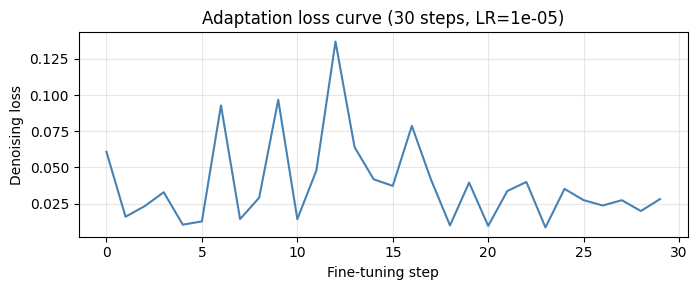

In [11]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(losses, color='steelblue', linewidth=1.5)
ax.set_xlabel('Fine-tuning step'); ax.set_ylabel('Denoising loss')
ax.set_title(f'Adaptation loss curve ({ADAPT_STEPS} steps, LR={ADAPT_LR})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
SAVE_DIR = './results/adaptation/'
os.makedirs(SAVE_DIR, exist_ok=True)
plt.savefig(f'{SAVE_DIR}/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8: After-Adaptation Evaluation

Evaluate the **adapted model** on the same drifted eval sequences (held out from fine-tuning). Also evaluate on clean data to check for catastrophic forgetting.

In [12]:
print('Evaluating ADAPTED model on drifted eval data...')
t0 = time.time()
res_drifted_after = quick_eval(eval_drifted, eval_idx, model_adapted)
lat_adapted = (time.time() - t0) / EVAL_SEQS * 1000

print('Evaluating ADAPTED model on clean eval data (forgetting check)...')
res_clean_after = quick_eval(eval_clean, eval_idx, model_adapted)

print(f'\nAdapted on drifted — ADE: {res_drifted_after["ADE"]:.4f}  FDE: {res_drifted_after["FDE"]:.4f}')
print(f'Adapted on clean   — ADE: {res_clean_after["ADE"]:.4f}  FDE: {res_clean_after["FDE"]:.4f}')

Evaluating ADAPTED model on drifted eval data...
Evaluating ADAPTED model on clean eval data (forgetting check)...

Adapted on drifted — ADE: 0.5836  FDE: 0.7340
Adapted on clean   — ADE: 0.4761  FDE: 0.6764


## Section 9: Before/After Summary Table

Consolidated comparison across all four conditions.

In [13]:
b_ade = res_clean_before['ADE']

rows = [
    {'Condition': 'Original — Clean',          'ADE': res_clean_before['ADE'],   'FDE': res_clean_before['FDE'],
     'ΔADE%': 0.0, 'Latency_ms': lat_clean},
    {'Condition': 'Original — Drifted',        'ADE': res_drifted_before['ADE'], 'FDE': res_drifted_before['FDE'],
     'ΔADE%': (res_drifted_before['ADE'] - b_ade) / b_ade * 100, 'Latency_ms': lat_drifted},
    {'Condition': 'Adapted  — Drifted',        'ADE': res_drifted_after['ADE'],  'FDE': res_drifted_after['FDE'],
     'ΔADE%': (res_drifted_after['ADE'] - b_ade) / b_ade * 100,  'Latency_ms': lat_adapted},
    {'Condition': 'Adapted  — Clean (forgetting)', 'ADE': res_clean_after['ADE'], 'FDE': res_clean_after['FDE'],
     'ΔADE%': (res_clean_after['ADE'] - b_ade) / b_ade * 100,    'Latency_ms': lat_adapted},
]

df_adapt = pd.DataFrame(rows)
print(df_adapt.to_string(index=False, float_format='%.4f'))

                    Condition    ADE    FDE   ΔADE%  Latency_ms
             Original — Clean 0.4738 0.6896  0.0000   1016.1124
           Original — Drifted 0.5637 0.7160 18.9571   1029.5815
           Adapted  — Drifted 0.5836 0.7340 23.1649   1048.8761
Adapted  — Clean (forgetting) 0.4761 0.6764  0.4801   1048.8761


## Section 10: Visualization — Before vs After

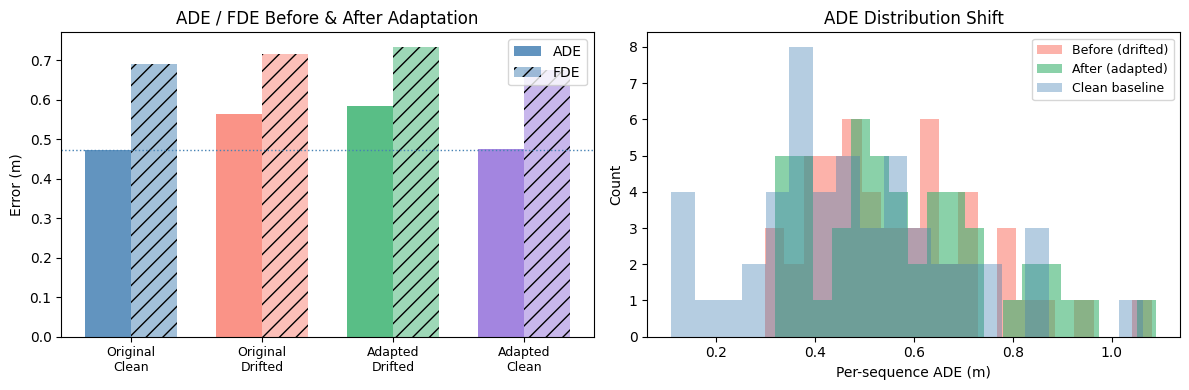

Saved: ./results/adaptation//adaptation_results.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── ADE comparison bar chart ─────────────────────────────────────────────────
ax = axes[0]
labels = ['Original\nClean', 'Original\nDrifted', 'Adapted\nDrifted', 'Adapted\nClean']
ades   = [res_clean_before['ADE'], res_drifted_before['ADE'],
           res_drifted_after['ADE'],  res_clean_after['ADE']]
fdes   = [res_clean_before['FDE'], res_drifted_before['FDE'],
           res_drifted_after['FDE'],  res_clean_after['FDE']]
colors = ['steelblue', 'salmon', 'mediumseagreen', 'mediumpurple']
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, ades, width, label='ADE', color=colors, alpha=0.85)
ax.bar(x + width/2, fdes, width, label='FDE', color=colors, alpha=0.5, hatch='//')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Error (m)'); ax.set_title('ADE / FDE Before & After Adaptation')
ax.legend()
ax.axhline(res_clean_before['ADE'], color='steelblue', linestyle=':', linewidth=1.0, label='baseline ADE')

# ── Per-sequence ADE distribution ────────────────────────────────────────────
ax2 = axes[1]
ax2.hist(res_drifted_before['per_ade'], bins=20, alpha=0.6, label='Before (drifted)', color='salmon')
ax2.hist(res_drifted_after['per_ade'],  bins=20, alpha=0.6, label='After (adapted)',  color='mediumseagreen')
ax2.hist(res_clean_before['per_ade'],   bins=20, alpha=0.4, label='Clean baseline',   color='steelblue')
ax2.set_xlabel('Per-sequence ADE (m)'); ax2.set_ylabel('Count')
ax2.set_title('ADE Distribution Shift')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/adaptation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {SAVE_DIR}/adaptation_results.png')

## Section 11: Model Size & Latency Comparison

Check that the adapted model has the same parameter count and similar latency — confirming adaptation adds no overhead.

In [15]:
params_orig    = sum(p.numel() for p in model_orig.parameters())
params_adapted = sum(p.numel() for p in model_adapted.parameters())

print('=== Model Size Comparison ===')
print(f'  Original  : {params_orig/1e6:.2f}M params')
print(f'  Adapted   : {params_adapted/1e6:.2f}M params  (same architecture, different weights)')

print('\n=== Latency Comparison ===')
print(f'  Clean inference  : {lat_clean:.1f} ms/seq')
print(f'  Drifted (orig)   : {lat_drifted:.1f} ms/seq')
print(f'  Drifted (adapted): {lat_adapted:.1f} ms/seq')

print('\n=== Recovery Summary ===')
gap_before = res_drifted_before['ADE'] - res_clean_before['ADE']
gap_after  = res_drifted_after['ADE']  - res_clean_before['ADE']
recovery   = (gap_before - gap_after) / gap_before * 100 if gap_before > 0 else 0
forgetting = (res_clean_after['ADE'] - res_clean_before['ADE']) / res_clean_before['ADE'] * 100
print(f'  ADE gap before adaptation: {gap_before:+.4f}')
print(f'  ADE gap after  adaptation: {gap_after:+.4f}')
print(f'  Recovery: {recovery:.1f}%  |  Forgetting: {forgetting:+.1f}%')

=== Model Size Comparison ===
  Original  : 28.40M params
  Adapted   : 28.40M params  (same architecture, different weights)

=== Latency Comparison ===
  Clean inference  : 1016.1 ms/seq
  Drifted (orig)   : 1029.6 ms/seq
  Drifted (adapted): 1048.9 ms/seq

=== Recovery Summary ===
  ADE gap before adaptation: +0.0898
  ADE gap after  adaptation: +0.1098
  Recovery: -22.2%  |  Forgetting: +0.5%


## Section 12: Save Results

In [16]:
df_adapt.to_csv(f'{SAVE_DIR}/adaptation_summary.csv', index=False)

# Save adapted model checkpoint
torch.save(model_adapted.state_dict(), f'{SAVE_DIR}/ckpt_adapted.pt')

print(f'Results saved to {SAVE_DIR}')
print('\n--- Final Table ---')
print(df_adapt[['Condition', 'ADE', 'FDE', 'ΔADE%']].to_string(index=False, float_format='%.4f'))

Results saved to ./results/adaptation/

--- Final Table ---
                    Condition    ADE    FDE   ΔADE%
             Original — Clean 0.4738 0.6896  0.0000
           Original — Drifted 0.5637 0.7160 18.9571
           Adapted  — Drifted 0.5836 0.7340 23.1649
Adapted  — Clean (forgetting) 0.4761 0.6764  0.4801
